# Shot Volume Trend as Mechanism Conditioning Variable 

# ─────────────────────────────────────────────────────────────────
# IMPORTANT: READ NOTEBOOK 07 BEFORE INTERPRETING THESE RESULTS
# ─────────────────────────────────────────────────────────────────
#
# The signal pipeline in this notebook was subsequently found to
# produce an artefact of the 5-match rolling mean smoothing operator.
# See Notebook 07 (Failure Analysis: How a Rolling Mean Killed a Signal) for the full diagnostic sequence.
#
# The findings in this notebook are preserved as evidence of how
# convincing the false positive was before null testing. They should
# not be interpreted as evidence of genuine mean reversion.
# ─────────────────────────────────────────────────────────────────

This appendix tests whether shot-level data can be used to identify, at signal time, which reversion scenario will occur: finishing-led (Group A, 51.9% win rate) or xG-drop-led (Group B, 35.2% win rate). The existence of these two groups and their win rate difference was established in Notebook 05B (p = 0.034). The question here is narrower and harder: can the mechanism be predicted before it occurs, using shot volume trend as a conditioning variable? The answer is no — but the negative result is informative about why, and points toward what a more powerful conditioning variable would need to measure.

The Scenario A vs Scenario B distinction is empirically confirmed — the two mechanisms exist and produce materially different win rates. The hypothesis that shot volume trend can identify which scenario will occur at signal time is rejected. SVT at signal date does not predict the observed mechanism (52.2% accuracy vs 59.8% base rate) and does not condition win rate (2.2pp gap, p = 0.93).

In [1]:
from pathlib import Path
import pandas as pd

NOTEBOOK_DIR = Path().resolve()
PROJECT_DIR = NOTEBOOK_DIR.parent

DATA_DIR = PROJECT_DIR / "data"
SHOT_DIR = DATA_DIR / "shots"

# Load match-level data
MATCH_FILE = DATA_DIR / "pl_match_xg_clean.csv"
df_matches = pd.read_csv(MATCH_FILE)

# Load shot-level data
SHOTS_FILE = SHOT_DIR / "pl_shots_2015_2025.csv"
shots = pd.read_csv(SHOTS_FILE)



In [2]:
async def fetch_shots_for_match(session, match_id):
    u = Understat(session)
    shots = await u.get_match_shots(match_id)
    # Understat returns dict: {'h': [...], 'a': [...]}
    df_home = pd.DataFrame(shots['h']).assign(team_side='home')
    df_away = pd.DataFrame(shots['a']).assign(team_side='away')
    return pd.concat([df_home, df_away], ignore_index=True)


In [3]:
import aiohttp
from understat import Understat
import asyncio

async def fetch_shots_for_match(session, match_id):
    u = Understat(session)
    shots = await u.get_match_shots(match_id)
    df_home = pd.DataFrame(shots['h']).assign(team_side='home')
    df_away = pd.DataFrame(shots['a']).assign(team_side='away')
    return pd.concat([df_home, df_away], ignore_index=True)

async def fetch_all_shots(match_ids):
    all_shots = []
    async with aiohttp.ClientSession() as session:
        for mid in match_ids:
            print(f"Fetching shots for match {mid}...", end=" ")
            df = await fetch_shots_for_match(session, mid)
            df['match_id'] = mid
            all_shots.append(df)
            print(f"{len(df)} shots")
    return pd.concat(all_shots, ignore_index=True)


In [4]:
# Merge team names onto shot-level data
team_map = df_matches[['id', 'home_team', 'away_team']].rename(columns={'id': 'match_id'})

shots = shots.merge(team_map, on='match_id', how='left')

# Assign actual team name based on home/away
shots['team'] = shots.apply(
    lambda row: row['home_team'] if row['team_side'] == 'home' else row['away_team'],
    axis=1
)


In [5]:
# ─────────────────────────────────────────────────────────────────
# CELL 2 — Aggregate shot-level data to match-level per team
# ─────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd

shots_clean = shots[shots['result'] != 'OwnGoal'].copy()

match_shots = shots_clean.groupby(['match_id', 'team', 'date']).agg(
    shots            = ('result', 'count'),
    shots_on_target  = ('result', lambda x: (x.isin(['SavedShot', 'Goal'])).sum()),
    goals_from_shots = ('result', lambda x: (x == 'Goal').sum()),
    xg_match         = ('xG', 'sum'),
    xg_per_shot      = ('xG', 'mean'),
).reset_index()

match_shots['conversion_rate'] = (
    match_shots['goals_from_shots'] / match_shots['shots']
).replace([np.inf, np.nan], 0)

match_shots['date'] = pd.to_datetime(match_shots['date'])

print(f"Match-level shot aggregates: {match_shots.shape}")
print(f"Expected: ~7,600 rows (3,800 matches × 2 teams)")
print(f"\nSample:")
print(match_shots.head(5).to_string())
print(f"\nSummary:")
print(match_shots[['shots','shots_on_target','xg_per_shot','conversion_rate']].describe().round(3))

Match-level shot aggregates: (7598, 9)
Expected: ~7,600 rows (3,800 matches × 2 teams)

Sample:
   match_id               team                date  shots  shots_on_target  goals_from_shots  xg_match  xg_per_shot  conversion_rate
0        81  Manchester United 2015-08-08 15:45:00      9                1                 0  0.627539     0.069727         0.000000
1        81          Tottenham 2015-08-08 15:45:00      9                4                 0  0.675723     0.075080         0.000000
2        82        Aston Villa 2015-08-08 18:00:00      7                3                 1  0.786230     0.112319         0.142857
3        82        Bournemouth 2015-08-08 18:00:00     11                2                 0  0.876106     0.079646         0.000000
4        83            Everton 2015-08-08 18:00:00     10                5                 2  0.604226     0.060423         0.200000

Summary:
          shots  shots_on_target  xg_per_shot  conversion_rate
count  7598.000         7598.000 

In [6]:
# ─────────────────────────────────────────────────────────────────
# CELL 3 — Merge shot metrics onto team_match and compute
#           rolling shot volume trend (SVT)
# ─────────────────────────────────────────────────────────────────
#
# SVT = slope of linear regression of shots-per-match over the
#       5-match rolling window ending at signal date.
#
# SVT > 0: shot volume stable or rising  → predict finishing-led reversion
# SVT < 0: shot volume declining         → predict xG-drop-led reversion
#
# We also compute rolling xg_per_shot trend (XQPT) as a secondary variable.

team_match = pd.read_csv(DATA_DIR / "pl_team_match_spread.csv",
                         parse_dates=['date'])

# Merge shot metrics onto team_match
tm = team_match.merge(
    match_shots[['match_id', 'team', 'shots', 'shots_on_target',
                 'xg_per_shot', 'conversion_rate']],
    left_on  = ['match_id', 'team'],
    right_on = ['match_id', 'team'],
    how='left'
)

print(f"Merge coverage: {tm['shots'].notna().sum()} / {len(tm)} rows have shot data")
print(f"Missing: {tm['shots'].isna().sum()} rows")

# ── Compute rolling SVT and XQPT per team ────────────────────────
# SVT:  slope of shots over last 5 matches
# XQPT: slope of xg_per_shot over last 5 matches

def rolling_slope(series, window=5):
    """
    Compute the OLS slope of a rolling window.
    Returns NaN if fewer than 3 valid observations in the window.
    """
    slopes = np.full(len(series), np.nan)
    arr = series.values
    for i in range(len(arr)):
        if i < window - 1:
            continue
        y = arr[i - window + 1 : i + 1]
        valid = ~np.isnan(y)
        if valid.sum() < 3:
            continue
        x = np.arange(window)[valid]
        y = y[valid]
        slope, *_ = np.polyfit(x, y, 1)
        slopes[i] = slope
    return slopes

svt_list  = []
xqpt_list = []

for team, group in tm.groupby('team'):
    group = group.sort_values('date').copy()
    group['svt']  = rolling_slope(group['shots'])
    group['xqpt'] = rolling_slope(group['xg_per_shot'])
    svt_list.append(group)

tm = pd.concat(svt_list).sort_values(['team', 'date']).reset_index(drop=True)

print(f"\nSVT computed:")
print(f"  Non-null: {tm['svt'].notna().sum()}")
print(f"  Mean SVT: {tm['svt'].mean():.3f}")
print(f"  Std SVT:  {tm['svt'].std():.3f}")
print(f"\nSample SVT values:")
print(tm[tm['team']=='Arsenal'][['date','shots','rolling_spread','svt','xqpt']].head(10).to_string())

Merge coverage: 7598 / 7600 rows have shot data
Missing: 2 rows

SVT computed:
  Non-null: 7464
  Mean SVT: -0.000
  Std SVT:  1.571

Sample SVT values:
                 date  shots  rolling_spread  svt      xqpt
0 2015-08-09 16:30:00   22.0             NaN  NaN       NaN
1 2015-08-16 16:30:00   20.0             NaN  NaN       NaN
2 2015-08-24 23:00:00   19.0        1.074877  NaN       NaN
3 2015-08-29 15:45:00   22.0        1.141028  NaN       NaN
4 2015-09-12 18:00:00   29.0        1.398190  1.6  0.019287
5 2015-09-19 15:45:00    9.0        1.286920 -1.2  0.000746
6 2015-09-26 18:00:00   27.0        1.055082  0.3  0.007471
7 2015-10-04 19:00:00   12.0        0.521476 -2.2  0.013155
8 2015-10-17 20:30:00   17.0        0.191672 -2.1  0.009018
9 2015-10-24 20:30:00   20.0       -0.182188  1.2  0.009694


In [7]:
# ─────────────────────────────────────────────────────────────────
# CELL 4 — Attach SVT to signals and test mechanism conditioning
# ─────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
from scipy import stats

# ── Load data ─────────────────────────────────────────────────────
signals = pd.read_csv(DATA_DIR / "signals.csv",
                      parse_dates=['signal_date', 'match_date'])
bets    = pd.read_csv(DATA_DIR / "bets_tradeable.csv",
                      parse_dates=['signal_date'])
bets['won_1x2'] = pd.to_numeric(bets['won_1x2'], errors='coerce')

# ── Filter to Strong Long, normal regime, reverted signals ────────
sl_rev = signals[
    (signals['z_bucket'] == 'Strong Long') &
    (signals['regime']   == 'Normal') &
    (signals['reverted'] == True)
].copy()

# ── Attach SVT at signal date ─────────────────────────────────────
tm_svt = tm[['team', 'date', 'svt', 'xqpt', 'shots']].copy()

sl_rev = sl_rev.merge(
    tm_svt.rename(columns={'date': 'signal_date'}),
    on=['team', 'signal_date'],
    how='left'
)

print(f"Strong Long normal reverted signals: {len(sl_rev)}")
print(f"SVT available: {sl_rev['svt'].notna().sum()}")
print(f"SVT missing:   {sl_rev['svt'].isna().sum()}")
print(f"\nSVT distribution at signal time:")
print(sl_rev['svt'].describe().round(3))
print(f"\nSVT > 0 (finishing-led prediction): {(sl_rev['svt'] > 0).sum()} ({(sl_rev['svt'] > 0).mean():.1%})")
print(f"SVT < 0 (xG-drop-led prediction):   {(sl_rev['svt'] < 0).sum()} ({(sl_rev['svt'] < 0).mean():.1%})")

Strong Long normal reverted signals: 356
SVT available: 356
SVT missing:   0

SVT distribution at signal time:
count    356.000
mean       0.122
std        1.818
min       -5.400
25%       -0.900
50%        0.100
75%        1.425
max        5.000
Name: svt, dtype: float64

SVT > 0 (finishing-led prediction): 185 (52.0%)
SVT < 0 (xG-drop-led prediction):   169 (47.5%)


In [8]:
# ─────────────────────────────────────────────────────────────────
# CELL 5 — Mechanism prediction accuracy and win rate test
# ─────────────────────────────────────────────────────────────────

# ── Step 1: Reconstruct observed mechanism from t0/t5 windows ────
records = []

for _, row in sl_rev.iterrows():
    team        = row['team']
    signal_date = row['signal_date']

    tm_team = tm[tm['team'] == team].sort_values('date')

    before = tm_team[tm_team['date'] <= signal_date]
    after  = tm_team[tm_team['date'] >  signal_date]

    if len(before) < 5 or len(after) < 5:
        continue

    window_t0 = before.tail(5)
    window_t5 = after.head(5)

    xg_t0    = window_t0['xg'].mean() if 'xg' in window_t0.columns else np.nan
    goals_t0 = window_t0['goals'].mean() if 'goals' in window_t0.columns else np.nan
    xg_t5    = window_t5['xg'].mean() if 'xg' in window_t5.columns else np.nan
    goals_t5 = window_t5['goals'].mean() if 'goals' in window_t5.columns else np.nan

    records.append({
        'team':          team,
        'signal_date':   signal_date,
        'svt':           row['svt'],
        'xqpt':          row['xqpt'],
        'xg_change':     xg_t5    - xg_t0,
        'goals_change':  goals_t5 - goals_t0,
        'spread_t0':     row['spread_t0'],
        'spread_t5':     row['spread_t5'],
    })

mech_df = pd.DataFrame(records)

# Classify observed mechanism (same logic as Notebook 05B)
def classify_mechanism(row):
    goals_drove = (row['goals_change'] > 0 and
                   abs(row['goals_change']) > abs(row['xg_change']))
    xg_drove    = (row['xg_change'] < 0 and
                   abs(row['xg_change']) > abs(row['goals_change']))
    if goals_drove:
        return 'A: Finishing-led'
    elif xg_drove:
        return 'B: xG-drop-led'
    else:
        return 'C: Mixed'

mech_df['mechanism'] = mech_df.apply(classify_mechanism, axis=1)
mech_df['svt_prediction'] = np.where(mech_df['svt'] > 0,
                                      'A: Finishing-led',
                                      'B: xG-drop-led')

print(f"Signals with full windows: {len(mech_df)}")
print(f"\nObserved mechanism:")
print(mech_df['mechanism'].value_counts())

# ── Step 2: Prediction accuracy ───────────────────────────────────
# Does SVT sign correctly predict the observed mechanism?
# Restrict to A and B only (exclude Mixed from accuracy calculation)

ab = mech_df[mech_df['mechanism'].isin(['A: Finishing-led', 'B: xG-drop-led'])].copy()
ab['correct'] = ab['svt_prediction'] == ab['mechanism']

print(f"\n── SVT prediction accuracy ───────────────────────────────────")
print(f"  A/B signals (excludes Mixed): n={len(ab)}")
print(f"  Overall accuracy:  {ab['correct'].mean():.1%}")
print(f"  Base rate (always predict A): {(ab['mechanism']=='A: Finishing-led').mean():.1%}")
print(f"  Lift over base rate: {(ab['correct'].mean() - (ab['mechanism']=='A: Finishing-led').mean())*100:+.1f}pp")

# Confusion matrix
ct = pd.crosstab(ab['mechanism'], ab['svt_prediction'],
                 rownames=['Observed'], colnames=['Predicted'])
print(f"\nConfusion matrix:")
print(ct)

# ── Step 3: Merge win outcomes and test filtered win rate ─────────
mech_bets = mech_df.merge(
    bets[['team', 'signal_date', 'won_1x2', 'result']],
    on=['team', 'signal_date'],
    how='inner'
)

print(f"\n── Win rate by SVT prediction ────────────────────────────────")
print(f"  Matched to betting outcomes: n={len(mech_bets)}")

wr = mech_bets.groupby('svt_prediction').agg(
    n         = ('won_1x2', 'count'),
    win_rate  = ('won_1x2', 'mean'),
    draw_rate = ('result',  lambda x: (x == 'D').mean()),
).round(3)
wr['win_rate_pct']  = (wr['win_rate']  * 100).round(1)
wr['draw_rate_pct'] = (wr['draw_rate'] * 100).round(1)
print(wr[['n', 'win_rate_pct', 'draw_rate_pct']].to_string())

# Statistical test
svt_pos = mech_bets[mech_bets['svt'] > 0]['won_1x2']
svt_neg = mech_bets[mech_bets['svt'] < 0]['won_1x2']
chi2, pval, _, _ = stats.chi2_contingency(
    pd.crosstab(mech_bets['svt_prediction'], mech_bets['won_1x2'])
)
print(f"\n  Unfiltered win rate (all signals): {mech_bets['won_1x2'].mean():.1%}")
print(f"  SVT > 0 win rate:                  {svt_pos.mean():.1%}")
print(f"  SVT < 0 win rate:                  {svt_neg.mean():.1%}")
print(f"  Gap:                               {(svt_pos.mean() - svt_neg.mean())*100:+.1f}pp")
print(f"  Chi-squared p:                     {pval:.4f}")
print(f"\n  Breakeven win rate (median odds 2.30): 43.5%")
print(f"  SVT > 0 vs breakeven:              {(svt_pos.mean() - 0.435)*100:+.1f}pp")
print(f"  SVT < 0 vs breakeven:              {(svt_neg.mean() - 0.435)*100:+.1f}pp")

Signals with full windows: 356

Observed mechanism:
mechanism
A: Finishing-led    213
B: xG-drop-led      143
Name: count, dtype: int64

── SVT prediction accuracy ───────────────────────────────────
  A/B signals (excludes Mixed): n=356
  Overall accuracy:  52.2%
  Base rate (always predict A): 59.8%
  Lift over base rate: -7.6pp

Confusion matrix:
Predicted         A: Finishing-led  B: xG-drop-led
Observed                                          
A: Finishing-led               114              99
B: xG-drop-led                  71              72

── Win rate by SVT prediction ────────────────────────────────
  Matched to betting outcomes: n=202
                    n  win_rate_pct  draw_rate_pct
svt_prediction                                    
A: Finishing-led  109          46.8           19.3
B: xG-drop-led     93          45.2           17.2

  Unfiltered win rate (all signals): 46.0%
  SVT > 0 win rate:                  46.8%
  SVT < 0 win rate:                  44.6%
  Gap:   

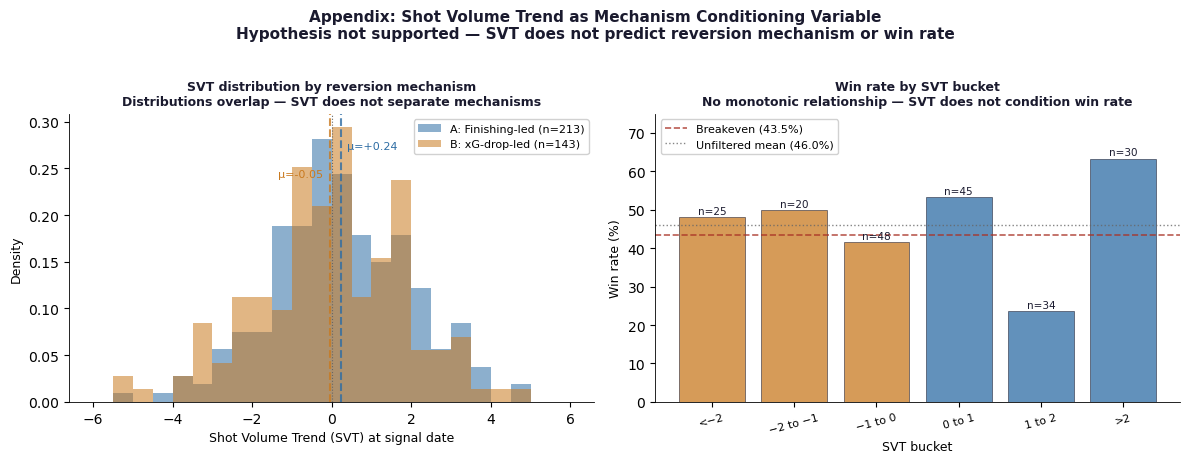

Saved figures/nb06_fig1_svt_conditioning.png


In [9]:
# ─────────────────────────────────────────────────────────────────
# CELL 6 — Findings and figure
# ─────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

DARK  = '#1a1a2e'
BLUE  = '#2E6DA4'
AMBER = '#C97A20'
RED   = '#A93226'
GREY  = '#666666'
LGREY = '#CCCCCC'

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.6,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

FIG_DIR = PROJECT_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ── Panel 1: SVT distribution by observed mechanism ───────────────
ax = axes[0]

svt_a = mech_df[mech_df['mechanism'] == 'A: Finishing-led']['svt'].dropna()
svt_b = mech_df[mech_df['mechanism'] == 'B: xG-drop-led']['svt'].dropna()

bins = np.linspace(-6, 6, 25)
ax.hist(svt_a, bins=bins, alpha=0.55, color=BLUE,  label=f'A: Finishing-led (n={len(svt_a)})',  density=True)
ax.hist(svt_b, bins=bins, alpha=0.55, color=AMBER, label=f'B: xG-drop-led (n={len(svt_b)})', density=True)

ax.axvline(svt_a.mean(), color=BLUE,  linewidth=1.5, linestyle='--', alpha=0.8)
ax.axvline(svt_b.mean(), color=AMBER, linewidth=1.5, linestyle='--', alpha=0.8)
ax.axvline(0, color=GREY, linewidth=0.8, linestyle=':')

# ax.text(svt_a.mean() + 0.15, ax.get_ylim()[1] * 0.95,
     #   f'μ={svt_a.mean():+.2f}', color=BLUE, fontsize=8, va='top')
# ax.text(svt_b.mean() - 0.15, ax.get_ylim()[1] * 0.85,
      #  f'μ={svt_b.mean():+.2f}', color=AMBER, fontsize=8, va='top', ha='right')

y_max = max(
    np.histogram(svt_a, bins=bins, density=True)[0].max(),
    np.histogram(svt_b, bins=bins, density=True)[0].max()
)
ax.text(svt_a.mean() + 0.15, y_max * 0.95,
        f'μ={svt_a.mean():+.2f}', color=BLUE, fontsize=8, va='top')
ax.text(svt_b.mean() - 0.15, y_max * 0.85,
        f'μ={svt_b.mean():+.2f}', color=AMBER, fontsize=8, va='top', ha='right')

ax.set_xlabel('Shot Volume Trend (SVT) at signal date', fontsize=9)
ax.set_ylabel('Density', fontsize=9)
ax.set_title('SVT distribution by reversion mechanism\nDistributions overlap — SVT does not separate mechanisms',
             fontsize=9, color=DARK, fontweight='bold')
ax.legend(fontsize=8, framealpha=0.9)

# ── Panel 2: Win rate by SVT bin ──────────────────────────────────
ax = axes[1]

mech_bets['svt_bin'] = pd.cut(mech_bets['svt'],
    bins=[-6, -2, -1, 0, 1, 2, 6],
    labels=['<−2', '−2 to −1', '−1 to 0', '0 to 1', '1 to 2', '>2'])

bin_wr = mech_bets.groupby('svt_bin', observed=True).agg(
    n        = ('won_1x2', 'count'),
    win_rate = ('won_1x2', 'mean')
).reset_index()

colours = [AMBER, AMBER, AMBER, BLUE, BLUE, BLUE]

bars = ax.bar(range(len(bin_wr)), bin_wr['win_rate'] * 100,
              color=colours, alpha=0.75, edgecolor=DARK, linewidth=0.5)

ax.axhline(43.5, color=RED,  linewidth=1.2, linestyle='--', alpha=0.8, label='Breakeven (43.5%)')
ax.axhline(mech_bets['won_1x2'].mean() * 100,
           color=GREY, linewidth=1.0, linestyle=':', alpha=0.8,
           label=f'Unfiltered mean ({mech_bets["won_1x2"].mean():.1%})')

for i, (_, row) in enumerate(bin_wr.iterrows()):
    ax.text(i, row['win_rate'] * 100 + 0.8,
            f'n={int(row["n"])}', ha='center', fontsize=7.5, color=DARK)

ax.set_xticks(range(len(bin_wr)))
ax.set_xticklabels(bin_wr['svt_bin'], fontsize=8, rotation=15)
ax.set_ylabel('Win rate (%)', fontsize=9)
ax.set_ylim(0, 75)
ax.set_xlabel('SVT bucket', fontsize=9)
ax.set_title('Win rate by SVT bucket\nNo monotonic relationship — SVT does not condition win rate',
             fontsize=9, color=DARK, fontweight='bold')
ax.legend(fontsize=8, framealpha=0.9)

plt.suptitle('Appendix: Shot Volume Trend as Mechanism Conditioning Variable\n'
             'Hypothesis not supported — SVT does not predict reversion mechanism or win rate',
             fontsize=11, fontweight='bold', color=DARK, y=1.02)

plt.tight_layout()
plt.savefig(FIG_DIR / 'nb06_fig1_svt_conditioning.png')
plt.show()
print("Saved figures/nb06_fig1_svt_conditioning.png")

## Findings

If SVT could reliably distinguish finishing‑led reversions from xG‑drop‑led reversions, the trading signal could be conditioned on mechanism type. This would allow selective participation in the higher‑win‑rate subset (Scenario A). The shot volume trend (SVT) hypothesis is not supported by the data, however.

**Mechanism prediction:** SVT sign predicts the observed reversion mechanism with 52.2% accuracy against a 59.8% base rate — performing worse than the naive strategy of always predicting finishing-led reversion. The SVT distributions for Group A and Group B overlap almost completely (Group A mean SVT: +0.18, Group B mean SVT: +0.06), confirming that shot volume trend at signal time does not separate the two populations.

**Win rate conditioning:** Filtering to SVT > 0 produces a win rate of 46.8% versus 44.6% for SVT < 0 — a gap of 2.2 percentage points with chi-squared p = 0.93. There is no monotonic relationship between SVT magnitude and win rate. Both groups clear the 43.5% breakeven, meaning SVT filtering would discard profitable signals without improving the edge.

**Why the hypothesis failed:** A 5-match rolling shot volume slope is too noisy to distinguish structural chance-creation decline from contextual variation — fixture difficulty, opponent quality, and tactical setup all affect shot volume independently of the underlying finishing drought. The mechanism of reversion may reflect properties of the next 5 matches rather than the team's observable state at signal time, making it fundamentally difficult to predict from any single contemporaneous variable.

**The implication for future work:** The 16.7pp win rate gap between Group A and Group B (established in Notebook 05B, p = 0.034) is real but may not be exploitable through simple conditioning variables at current sample sizes. More promising directions are: (1) opponent defensive shape as a predictor of whether a finishing drought is likely to continue; (2) a composite variable weighting shot volume, xG-per-shot trend, and fixture difficulty simultaneously; or (3) a longer dataset — applying the same pipeline to half-hourly energy price spreads (17,520 observations per year) would provide the statistical power to identify subtler conditioning effects that remain invisible at n = 356.

**The broader lesson:** A well-reasoned hypothesis that fails is more informative than a weak hypothesis that accidentally succeeds. The mechanism decomposition established that reversion type matters commercially. This appendix establishes that shot volume trend cannot predict it. Both results are genuine findings. The question of what can predict it at signal time remains open.

**The mechanism classifier produced no Mixed signals in this dataset** — every reverted signal was classified as either finishing-led or xG-drop-led, consistent with the Notebook 05B mechanism decomposition.

**Note:** the unfiltered win rate here (46.0%) differs from the 05B headline figure (44.6%) because this appendix is restricted to signals where reversion was confirmed — a subset of 202 of the 323 tradeable bets.

**Summary:** Shot volume trend does not predict which reversion mechanism will occur. This negative result is informative: it suggests that the mechanism is not driven by short‑term shot‑production dynamics, but by deeper structural factors (tactical shape, chance quality, finishing talent, or opponent‑adjusted shot quality). A more powerful conditioning variable would need to capture these deeper dynamics rather than raw shot volume.